# Screening Rates

Consider a nuclear fusion between two ions characterized by their atomic number, $Z$, and atomic weight number, $A$, 
surrounded by a sea of electrons.

$$(Z_1, A_1) + (Z_2, A_2) \rightarrow (Z_1 + Z_2, A_1 + A_2)$$

The electron screening effect reduces the effective Coulomb potential barrier that the ions must overcome for fusion to take place, causing an enhancement to the nuclear reaction rates. Suppose the unscreened rate is represented by $R_\mathrm{uns}$, then screened rate is

$$R_\mathrm{scn} = R_\mathrm{uns} \exp{(h)}$$

where $h$ characterizes the screening magnitude. $h$ generally depends on the density, temperature, composition, as well as $Z$ and $A$ of the two nuclei of the entrance channel, i.e.

$$h = h(\rho, T, X_k, Z_1, A_1, Z_2, A_2)$$

## Screening implementations

pynucastro currently has 4 screening implementations that computes $h$ for the fusion process between two ions:

* {py:func}`screen5 <pynucastro.screening.screen.screen5>` based on {cite:t}`Wallace:1982`
* {py:func}`potekhin_1998 <pynucastro.screening.screen.potekhin_1998>` based on {cite:t}`chabrier_potekhin:1998`
* {py:func}`chugunov_2007 <pynucastro.screening.screen.chugunov_2007>` based on {cite:t}`chugunov:2007`
* {py:func}`chugunov_2009 <pynucastro.screening.screen.chugunov_2009>` based on {cite:t}`chugunov:2009`

Each of these use various approximations to account for the influence of the plasma on screening the electric charge of the nuclei that are fusing.

## N-body Reaction

Now consider a general reaction of the from:

$$ R_1 + R_2 + R_3 + ... + R_N \rightarrow P_1 + P_2 + P_3 + ... + P_M$$

In order to extend the screening routine for a binary nuclear reaction to a general N-body reaction, consider the formation of an intermediate composite nuclei, $O$, i.e.

$$ R_1 + R_2 + R_3 + ... + R_N \rightarrow O_{R_1 + R_2} + R_3 + ... + R_N \rightarrow P_1 + P_2 + P_3 + ... + P_M$$

By breaking up the N-body reaction into N-1 sub-reaction with the formation of intermedite composite nuclei, the overall screening magnitude is then

$$h(R_1, R_2, R_3, ..., R_N) = h(R_1, R_2) + h(R_1 + R_2, R_3) + ... + h(R_1 + R_2 + ... + R_{N-1}, R_N)$$

```{note}
If the screening routine for a binary reaction takes the form:

$$ h = \frac{\mu^c(Z_1) + \mu^c(Z_2) - \mu^(Z_1 + Z_2)}{k_B T} $$

then it is straight forward to see that with the consideration of the formation of intermediate composite nuclei,
$h$ for a N-body reaction takes the form

$$ h = \frac{\mu^c(Z_1) + \mu^c(Z_2) + \mu^c(Z_3) + ... - \mu^(Z_1 + Z_2 + Z_3 + ... + Z_N)}{k_B T} $$

The only screening routine in pynucastro that takes this form is ``potekhin_1998``
```

In [1]:
import math
import pynucastro as pyna

For each rate, the reactant ion pairs needed to compute the overall screening factor is stored in the attribute `screening_pairs`.
A simple demonstration with the triple alpha rate is the following

In [2]:
reaclib_library = pyna.ReacLibLibrary()
triple_alpha = reaclib_library.get_rate_by_name("a(aa,g)c12")
triple_alpha.screening_pairs

[(He4, He4), (He4, Be8)]

Here we see that there are two screening pairs for the triple alpha rate. The first step involves two ${}^4\mathrm{He}$ producing ${}^8\mathrm{Be}$, and the second step involves fusing ${}^4\mathrm{He}$ and ${}^8\mathrm{Be}$ giving the final product ${}^{12}\mathrm{C}$,
i.e.

$$ {}^4\mathrm{He} + {}^4\mathrm{He} + {}^4\mathrm{He} \rightarrow {}^4\mathrm{He} + {}^8\mathrm{Be} \rightarrow {}^{12}\mathrm{C} $$

## Using screening

To compute the screening factor for a rate, we need to know the entire composition (since the electron number density matters) as well as the two nuclei involved in the reaction.  There are two special types that store this information:

* {py:obj}`PlasmaState <pynucastro.screening.screen.PlasmaState>` : stores the aggregate information about the entire plasma
* {py:obj}`ScreenFactors <pynucastro.screening.screen.ScreenFactors>` : stores the information about the two nuclei

We create these objects separate before we call the screening routine since there are some computational expensive calculations here that don't change with repeated calls.

Here we create a `PlasmaState` that knows about the conditions where the screening is taking place and then we use that to compute the screening factor for a rate.  The helper function
{py:func}`make_plasma_state <pynucastro.screening.screen.make_plasma_state>` can create the `PlasmaState` object

In [3]:
nuclei = [pyna.Nucleus("h1"),
          pyna.Nucleus("he4"),
          pyna.Nucleus("c12"),
          pyna.Nucleus("o16"),
          pyna.Nucleus("n14"),
          pyna.Nucleus("ca40")]

comp = pyna.Composition(nuclei)
comp.set_solar_like()

dens = 1.e6
temp = 1.e8

plasma = pyna.make_plasma_state(temp, dens, comp.get_molar())

Now let's get the ${}^{12}\mathrm{C}(\alpha,\gamma){}^{16}\mathrm{O}$ rate and compute the screening factor

In [4]:
rfilter = pyna.RateFilter(reactants=["c12", "he4"], products=["o16"])
r = reaclib_library.filter(rfilter).get_rates()[0]
r

C12 + He4 ⟶ O16 + 𝛾

For the rate, we need the `ScreenFactors` object

In [5]:
scn_fac = pyna.make_screen_factors(r.ion_screen[0], r.ion_screen[1])

Finally, we'll select the Chugunov (2009) screening and compute the screening factor.  All of the needed thermodynamic information is contained in the `PlasmaState` and all of the needed
reaction rate information is contained in the `ScreenFactors`

```{note}
All screening routines return $h$ = log(screening). Therefore, in order to get the actual multiplicative rate enhancement factor, we need to do an `exp()` afterwards.
```

In [6]:
from pynucastro.screening import chugunov_2009

In [7]:
log_scn = chugunov_2009(plasma, scn_fac)
scn = math.exp(log_scn)
print(f"{scn:12.8f}")

  4.42076841


In this case, we see that screening enhances the rate by over 4 times!

## Screening pair set

For a {py:obj}`RateCollection <pynucastro.networks.rate_collection.RateCollection>` or a network derived from it, there are a lot of rates that will need to be screened, and some might have the same nuclei that need to be screened.  A "screening pair set" keeps track of all the unique pairs of reactants used for screening the rates.

The screening pair set is a ``set`` of tuples that contain pairs of nuclei that need a screening factor computed.

Here's an example: let's build a helium and carbon burning network.

In [8]:
mynet = reaclib_library.linking_nuclei(["p", "n", "he4", "c12", "o16",
                                        "na23", "mg24", "ne20"])
pynet = pyna.PythonNetwork(libraries=[mynet])

From the `RateCollection`, we can get the screening pair set using the {py:func}`get_screening_pair_set <pynucastro.screening.screening_util.get_screening_pair_set>` function:

In [9]:
from pynucastro.screening import get_screening_pair_set
screening_pair_set = get_screening_pair_set(pynet.get_rates())

In [10]:
for s in screening_pair_set:
    print(s)

(He4, C12)
(C12, C12)
(He4, He4)
(He4, O16)
(He4, Ne20)
(p, Na23)
(C12, O16)
(He4, Mg24)
(He4, Be8)


## Screening and a python network

When we write out the module that defines a python network, it contains all of the information needed to define the righthand side and Jacobian.  By default, screening is not used, but the `rhs` and `jacobian` functions can take an optional argument that is the name of the screening function to use.

Here we demonstrate this.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [12]:
pynet.write_network("cburn.py")
import cburn

First we'll run with screening.  Here we pass the name of the screening function to the `rhs` and `jacobian` function through the `args` keyword

We'll pick conditions appropriate for the center of a Chandra mass white dwarf just after a carbon flame ignites.

In [13]:
rho = 1.e9
T = 2.e9

X0 = np.zeros(cburn.nnuc)
X0[cburn.jc12] = 0.5
X0[cburn.jo16] = 0.5

Y0 = X0/cburn.A

tmax = 1000.0

sol = solve_ivp(cburn.rhs, [0, tmax], Y0, method="BDF", jac=cburn.jacobian,
                dense_output=True, args=(rho, T, chugunov_2009), rtol=1.e-6, atol=1.e-10)

Now we run without screening:

In [14]:
sol_noscreen = solve_ivp(cburn.rhs, [0, tmax], Y0, method="BDF", jac=cburn.jacobian,
                         dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-10)

and we can plot the two cases together.  The non-screened X's will be shown with a dotted line.

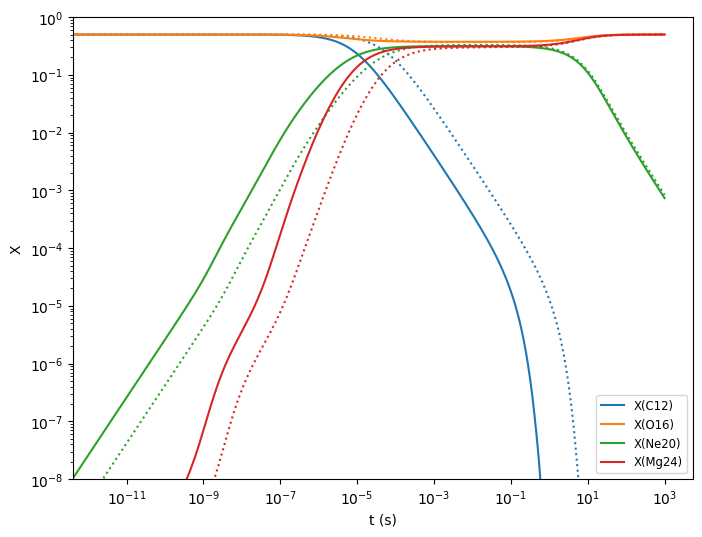

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

threshold = 1.e-4

icolor = 0
for i in range(cburn.nnuc):
    if (sol.y[i,:]).max() > threshold:
        ax.loglog(sol.t, sol.y[i,:] * cburn.A[i],
                  label=f"X({cburn.names[i].capitalize()})",
                  color=f"C{icolor}")
        ax.loglog(sol_noscreen.t, sol_noscreen.y[i,:] * cburn.A[i],
                  linestyle=":", color=f"C{icolor}")
        icolor += 1
        
ax.set_ylim(1.e-8, 1.0)
ax.legend(fontsize="small")
ax.set_xlabel("t (s)")
ax.set_ylabel("X")

fig.set_size_inches((8, 6))

As expected, using screening makes the carbon burn much more quickly.